<a href="https://colab.research.google.com/github/FredyVG15/Entregas-/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DESCOMPOSICIÓN CANÓNICA**



**1.-Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.**





In [1]:
import sympy as sp
import networkx as nx #Para visualizar estructura del proceso
import matplotlib.pyplot as plt #para crear gráficas

In [2]:
import numpy as np
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

# Para dibujar la Matriz de transición P
P = np.array(
    [[1/4,   0,   0,   0,   0,   0, 3/4],
    [1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
    [  0,   0, 2/5, 1/5, 2/5,   0,   0],
    [  0,   0, 1/2, 1/2,   0,   0,   0],
    [  0,   0,   0, 1/2, 1/2,   0,   0],
    [  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
    [4/5,   0,   0,   0,   0,   0, 1/5]]
)

print("Matriz de transición P:")
print(P)

Matriz de transición P:
[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


Para dibujar el diagrama de transición, utilizamos lo siguiente:

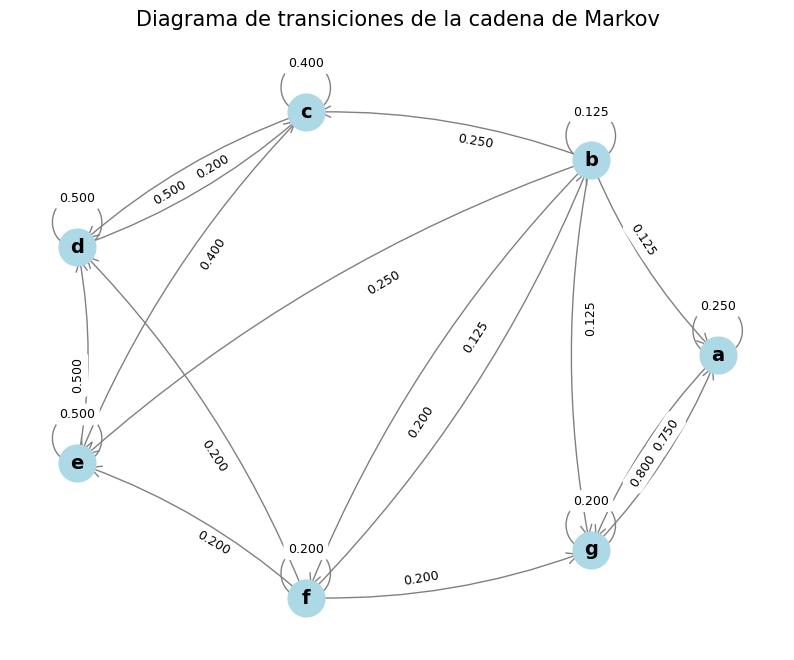

In [3]:
# Crea el grafo dirigido
G = nx.DiGraph()

# Agrega los  nodos
G.add_nodes_from(estados)

# Agrega aristas con probabilidades > 0
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        prob = P[i, j]
        if prob > 0:
            G.add_edge(origen, destino, weight=prob)

# Coloca los nodos en círculo para mejor visualización
pos = nx.circular_layout(G)

# Para dibujarlos nodos y aristas
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray',
                       connectionstyle='arc3,rad=0.1')

#Coloca etiquetas de aristas (probabilidades)
edge_labels = {(u, v): f"{d['weight']:.3f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.4)

plt.title("Diagrama de transiciones de la cadena de Markov", fontsize=15)
plt.axis('off')
plt.show()

**Análisis teórico**

- El conjunto $\{a, g\}$ es cerrado (solo se comunican entre sí).
- $\{c, d, e\}$ también forma una clase cerrada.
- $\{b, f\}$ son transitoria.

**Entonces identificamos:**

- Transientes: $\{b, f\}$
- Recurrentes:
  - Clase 1: $\{a, g\}$
  - Clase 2: $\{c, d, e\}$


**2. ¿La matriz tiene o no distribución límite?**

Para determinar si una Cadena de Markov posee una distribución límite única (un vector de estado estable $\pi$ que sea independiente del estado inicial), la cadena debe cumplir tres condiciones: debe ser irreducible, recurrente positiva y aperiódica.

Comencemos identificando las clases de comunicación analizando las transiciones posibles ($p_{ij} > 0$):

Desde $a$ y $g$: El estado $a$ se comunica con $g$ y consigo mismo. El estado $g$ se comunica con $a$ y consigo mismo. Por lo tanto, forman una clase cerrada: $C_1 = \{a, g\}$. Al ser cerrada y finita, es recurrente. Como $p_{aa} = 1/4 > 0$, es aperiódica.

Desde $c, d, e$: El estado $c$ lleva a $d$ y $e$. El estado $d$ lleva de regreso a $c$. El estado $e$ lleva a $d$ (y de ahí a $c$). Ninguno de estos estados transiciona hacia $a, b, f$ o $g$. Forman otra clase cerrada: $C_2 = \{c, d, e\}$. Al ser cerrada y finita, es recurrente. Como $p_{cc} = 2/5 > 0$, es aperiódica.

Desde $b$ y $f$: El estado $b$ tiene probabilidad de transición hacia $C_1$ (vía $a$ y $g$) y hacia $C_2$ (vía $c$ y $e$). El estado $f$ también transiciona hacia ambas clases. Como pueden salir de sus estados y entrar a clases absorbentes de las cuales no pueden regresar, $b$ y $f$ forman una clase transitoria: $T = \{b, f\}$.

**Conclusión:**

Dado que la matriz tiene múltiples clases cerradas ($C_1$ y $C_2$), la Cadena de Markov es reducible. Por lo tanto, NO tiene una distribución límite global y única. El comportamiento asintótico dependerá del estado inicial. Sin embargo, como todas las clases recurrentes son aperiódicas, sí existe el límite de la matriz $\lim_{n\to\infty} P^n$.

**3. Descomposición canónica, límite de $P^n$ y comparación.**


Para encontrar el límite, reordenamos los estados agrupando primero las clases recurrentes y al final los estados transitorios: $a, g$ ($C_1$), $c, d, e$ ($C_2$), y finalmente $b, f$ (Transitorios).

Descomposición Canónica de la Matriz ($\tilde{P}$)Reordenando filas y columnas bajo el esquema $\tilde{P} = \begin{pmatrix} P_1 & 0 & 0 \\ 0 & P_2 & 0 \\ R_1 & R_2 & Q \end{pmatrix}$:

$$ \tilde{P} = \begin{pmatrix}
1/4 & 3/4 & 0 & 0 & 0 & 0 & 0 \\
4/5 & 1/5 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 2/5 & 1/5 & 2/5 & 0 & 0 \\
0 & 0 & 1/2 & 1/2 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/2 & 1/2 & 0 & 0 \\
1/8 & 1/8 & 1/4 & 0 & 1/4 & 1/8 & 1/8 \\
0 & 1/5 & 0 & 1/5 & 1/5 & 1/5 & 1/5
\end{pmatrix} $$

De aquí extraemos las submatrices:

$P_1$ (Clase $C_1$): $\begin{pmatrix} 1/4 & 3/4 \\ 4/5 & 1/5 \end{pmatrix}$

$P_2$ (Clase $C_2$): $\begin{pmatrix} 2/5 & 1/5 & 2/5 \\ 1/2 & 1/2 & 0 \\ 0 & 1/2 & 1/2 \end{pmatrix}$

$Q$ (Transitorios $b, f$ entre sí): $\begin{pmatrix} 1/8 & 1/8 \\ 1/5 & 1/5 \end{pmatrix}$

$R_1$ (Transitorios hacia $C_1$): $\begin{pmatrix} 1/8 & 1/8 \\ 0 & 1/5 \end{pmatrix}$

$R_2$ (Transitorios hacia $C_2$): $\begin{pmatrix} 1/4 & 0 & 1/4 \\ 0 & 1/5 & 1/5 \end{pmatrix}$

**Distribuciones límite de las submatrices**

Para las clases recurrentes, calculamos sus vectores de estado estable resolviendo $\pi P_k = \pi$ con $\sum \pi_i = 1$.Para $C_1$ ($P_1$):$$ \pi^{(1)} = \left( \frac{16}{31}, \frac{15}{31} \right) $$Para $C_2$ ($P_2$):$$ \pi^{(2)} = \left( \frac{1}{3}, \frac{2}{5}, \frac{4}{15} \right) $$

**Análisis de los estados transitorios**

Para saber cómo se distribuyen los límites de los estados $b$ y $f$, calculamos las probabilidades de que sean absorbidos por $C_1$ o $C_2$.

**Matriz Fundamental $N = (I - Q)^{-1}$:**$$ N = \left[ \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} - \begin{pmatrix} 1/8 & 1/8 \\ 1/5 & 1/5 \end{pmatrix} \right]^{-1} = \begin{pmatrix} 32/27 & 5/27 \\ 8/27 & 35/27 \end{pmatrix} $$

**Probabilidades de absorción hacia las clases ($A_k = N R_k \mathbf{1}$):**

Hacia $C_1$:$$ A_1 = \begin{pmatrix} 32/27 & 5/27 \\ 8/27 & 35/27 \end{pmatrix} \begin{pmatrix} 1/4 \\ 1/5 \end{pmatrix} = \begin{pmatrix} 1/3 \\ 1/3 \end{pmatrix} $$Hacia $C_2$:$$ A_2 = \begin{pmatrix} 32/27 & 5/27 \\ 8/27 & 35/27 \end{pmatrix} \begin{pmatrix} 1/2 \\ 2/5 \end{pmatrix} = \begin{pmatrix} 2/3 \\ 2/3 \end{pmatrix} $$Ambos estados transitorios tienen $1/3$ de probabilidad de caer en $C_1$ y $2/3$ de caer en $C_2$.

**Límite de la potencia n-ésima ($P^\infty = \lim_{n \to \infty} P^n$)**

Reuniendo los cálculos y volviendo al orden original de la matriz $(a, b, c, d, e, f, g)$, la matriz límite es:

$$ P^\infty = \begin{pmatrix} 16/31 & 0 & 0 & 0 & 0 & 0 & 15/31 \\ 16/93 & 0 & 2/9 & 4/15 & 8/45 & 0 & 15/93 \\ 0 & 0 & 1/3 & 2/5 & 4/15 & 0 & 0 \\ 0 & 0 & 1/3 & 2/5 & 4/15 & 0 & 0 \\ 0 & 0 & 1/3 & 2/5 & 4/15 & 0 & 0 \\ 16/93 & 0 & 2/9 & 4/15 & 8/45 & 0 & 15/93 \\ 16/31 & 0 & 0 & 0 & 0 & 0 & 15/31 \end{pmatrix} $$

**Comparación Final**

Al comparar la matriz límite total $P^\infty$ con las distribuciones de las submatrices, observamos:



*   **Aislamiento de Clases:** Las filas de los estados recurrentes ($a, g$ y $c,
d, e$) son idénticas a sus respectivas distribuciones estacionarias $\pi^{(1)}$ y $\pi^{(2)}$. Si el proceso inicia en una clase cerrada, la probabilidad asintótica de salir de ella es $0$.
*   **Combinación Lineal en Transitorios:** Las filas correspondientes a los estados transitorios ($b$ y $f$) convergen a $0$ en sus propias columnas. Sus distribuciones finales son una combinación lineal convexa exacta de las distribuciones límite de las submatrices, ponderadas por las probabilidades de absorción calculadas previamente ($1/3$ para la submatriz 1 y $2/3$ para la submatriz 2).



**4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.**

In [4]:
from fractions import Fraction#permite trabajar con fracciones exactas (evita errores de redondeo)
import numpy as np

def encontrar_sccs(adj): #efine una función que encuentra componentes fuertemente conexas (SCCs) en un grafo.

    n = len(adj)#Número de nodos del grafo.
    visitado = [False] * n #Lista para marcar nodos visitados.
    orden = []#Lista que guardará el orden de finalización del DFS.

    def dfs1(u):
        visitado[u] = True
        for v in adj[u]:
            if not visitado[v]:
                dfs1(v)
        orden.append(u)

    for i in range(n):
        if not visitado[i]:
            dfs1(i)

    # Grafo transpuesto
    radj = [[] for _ in range(n)]
    for u in range(n):
        for v in adj[u]:
            radj[v].append(u)

    visitado = [False] * n
    sccs = []

    def dfs2(u, componente):
        visitado[u] = True
        componente.append(u)
        for v in radj[u]:
            if not visitado[v]:
                dfs2(v, componente)

    for u in reversed(orden):
        if not visitado[u]:
            comp = []
            dfs2(u, comp)
            sccs.append(comp)
    return sccs

#Calcula y muestra la descomposición canónica de una matriz estocástica P.
    #Parámetros:
    #P : list of list of Fraction   -- matriz cuadrada de transición (fracciones exactas)

def descomposicion_canonica(P, etiquetas=None):#Función principal que calcula la forma canónica.

    n = len(P) #Número de estados.
    # Matriz de adyacencia: arista si P[i][j] > 0
    adj = [[] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if P[i][j] > 0:
                adj[i].append(j)

    sccs = encontrar_sccs(adj)

    recurrentes = []
    transitorios = []
    for comp in sccs:
        # Una clase es cerrada (recurrente) si no hay aristas hacia afuera
        es_cerrada = True
        for u in comp:
            for v in adj[u]:
                if v not in comp:
                    es_cerrada = False
                    break
            if not es_cerrada:
                break
        if es_cerrada:
            recurrentes.append(sorted(comp))   #para ordenar dentro de la clase
        else:
            transitorios.extend(comp)

    # Para Ordenar las clases recurrentes por su primer elemento (o índice original)
    recurrentes.sort(key=lambda x: x[0])
    transitorios = sorted(transitorios)

    nuevo_orden = []
    for comp in recurrentes:
        nuevo_orden.extend(comp)
    nuevo_orden.extend(transitorios)

    # Mostrar etiquetas reordenadas
    if etiquetas:
        etiquetas_ordenadas = [etiquetas[i] for i in nuevo_orden]
        print("Orden canónico de estados:", etiquetas_ordenadas)
    else:
        print("Índices en orden canónico:", nuevo_orden)

    # Construir matriz canónica
    P_canon = []
    for i in nuevo_orden:
        fila = [P[i][j] for j in nuevo_orden]
        P_canon.append(fila)

    print("\nMatriz en forma canónica:")
    for fila in P_canon:
        print([str(x) for x in fila])

    # Tamaños de cada bloque
    tamanos_rec = [len(comp) for comp in recurrentes]
    t = len(transitorios)
    inicio = 0

    # Submatrices P_i (clases recurrentes)
    for idx, tam in enumerate(tamanos_rec):
        bloque = []
        for i in range(inicio, inicio + tam):
            bloque.append(P_canon[i][inicio:inicio + tam])
        print(f"\nP{idx+1} (clase recurrente {idx+1}):")
        for fila in bloque:
            print([str(x) for x in fila])
        inicio += tam

    # Submatriz Q (transitorios entre sí)
    Q = []
    for i in range(n - t, n):
        Q.append(P_canon[i][n - t:])
    print("\nQ (transitorios entre sí):")
    for fila in Q:
        print([str(x) for x in fila])

    # Submatrices R_i (de transitorios hacia cada clase recurrente)
    inicio = 0
    for idx, tam in enumerate(tamanos_rec):
        R = []
        for i in range(n - t, n):
            R.append(P_canon[i][inicio:inicio + tam])
        print(f"\nR{idx+1} (de transitorios a clase recurrente {idx+1}):")
        for fila in R:
            print([str(x) for x in fila])
        inicio += tam

    return P_canon, recurrentes, transitorios


# Ejemplo con la matriz anexa del problema concerniente

f = Fraction
P_ejemplo = [
    [f(1,4), f(0,1), f(0,1), f(0,1), f(0,1), f(0,1), f(3,4)],  # a
    [f(1,8), f(1,8), f(1,4), f(0,1), f(1,4), f(1,8), f(1,8)],  # b
    [f(0,1), f(0,1), f(2,5), f(1,5), f(2,5), f(0,1), f(0,1)],  # c
    [f(0,1), f(0,1), f(1,2), f(1,2), f(0,1), f(0,1), f(0,1)],  # d
    [f(0,1), f(0,1), f(0,1), f(1,2), f(1,2), f(0,1), f(0,1)],  # e
    [f(0,1), f(1,5), f(0,1), f(1,5), f(1,5), f(1,5), f(1,5)],  # f
    [f(4,5), f(0,1), f(0,1), f(0,1), f(0,1), f(0,1), f(1,5)],  # g
]
etiquetas = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

print(" DESCOMPOSICIÓN CANÓNICA")
descomposicion_canonica(P_ejemplo, etiquetas)

 DESCOMPOSICIÓN CANÓNICA
Orden canónico de estados: ['a', 'g', 'c', 'd', 'e', 'b', 'f']

Matriz en forma canónica:
['1/4', '3/4', '0', '0', '0', '0', '0']
['4/5', '1/5', '0', '0', '0', '0', '0']
['0', '0', '2/5', '1/5', '2/5', '0', '0']
['0', '0', '1/2', '1/2', '0', '0', '0']
['0', '0', '0', '1/2', '1/2', '0', '0']
['1/8', '1/8', '1/4', '0', '1/4', '1/8', '1/8']
['0', '1/5', '0', '1/5', '1/5', '1/5', '1/5']

P1 (clase recurrente 1):
['1/4', '3/4']
['4/5', '1/5']

P2 (clase recurrente 2):
['2/5', '1/5', '2/5']
['1/2', '1/2', '0']
['0', '1/2', '1/2']

Q (transitorios entre sí):
['1/8', '1/8']
['1/5', '1/5']

R1 (de transitorios a clase recurrente 1):
['1/8', '1/8']
['0', '1/5']

R2 (de transitorios a clase recurrente 2):
['1/4', '0', '1/4']
['0', '1/5', '1/5']


([[Fraction(1, 4),
   Fraction(3, 4),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1)],
  [Fraction(4, 5),
   Fraction(1, 5),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1)],
  [Fraction(0, 1),
   Fraction(0, 1),
   Fraction(2, 5),
   Fraction(1, 5),
   Fraction(2, 5),
   Fraction(0, 1),
   Fraction(0, 1)],
  [Fraction(0, 1),
   Fraction(0, 1),
   Fraction(1, 2),
   Fraction(1, 2),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1)],
  [Fraction(0, 1),
   Fraction(0, 1),
   Fraction(0, 1),
   Fraction(1, 2),
   Fraction(1, 2),
   Fraction(0, 1),
   Fraction(0, 1)],
  [Fraction(1, 8),
   Fraction(1, 8),
   Fraction(1, 4),
   Fraction(0, 1),
   Fraction(1, 4),
   Fraction(1, 8),
   Fraction(1, 8)],
  [Fraction(0, 1),
   Fraction(1, 5),
   Fraction(0, 1),
   Fraction(1, 5),
   Fraction(1, 5),
   Fraction(1, 5),
   Fraction(1, 5)]],
 [[0, 6], [2, 3, 4]],
 [1, 5])